#### Author's Information:
        Author : Ali Rizvi.
        Stu ID : 2410057
        Module : HEP502 of MSc Computer Sciences with Artificial Intelligence.
        Title  : Comparative Evaluation of MLP and CNN on Fashion-MNIST.
        Purpose: Final Assessment
---

| #| ## of Notebook | Title of Notebook |
|--|---|---|
| 1st | 00 | Data Loading and Sanity Checks |
| 2| 01 | Baseline MLP |
| **3**| **02** | **Baseline CNN** |
| 4| 03 | Regularisation Experiments |
| 5| 04 | Depth and Capacity Variance |
| 6| 05 | Robustness Testing |
| 7| 06 | Consolidated Analysis |

**This is Notebook 02,** 3nd of this 7-notebook series. The following are the goals of this notebook:
## Goals:
1) Load prepared data (train/val/test)
2) Build a simple CNN baseline
3) Train with fixed settings (no tuning yet)
4) Evaluate and plot learning curves
5) Save model artefacts like metrics and figures.

**This notebook contains implementation of baseline CNN with identical settings of baseline MLP**

#### Importing libraries

In [20]:
import json
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

#### Setting up reproductibility and output folders

In [21]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [22]:
OUTPUT_DIR = Path("outputs")
FIG_DIR = OUTPUT_DIR / "figures"
LOG_DIR = OUTPUT_DIR / "logs"
MODEL_DIR = OUTPUT_DIR / "models"

directories = [OUTPUT_DIR, FIG_DIR, LOG_DIR, MODEL_DIR]

for directory in directories:
    directory.mkdir(parents=True, exist_ok=True)
    
print(f"Outputs will be saved to: {OUTPUT_DIR.resolve()}")

Outputs will be saved to: C:\Users\ALI\PG\HEP502_work\alirizvi_2410057_hep502\code_mlp_vs_cnn\outputs


### Load prepared data
Refer to `00 Data loading and Sanity checks.ipynb`

In [23]:
data_path = OUTPUT_DIR / "fashion_mnist_prepared_00.npz"

assert data_path.exists(), f"Missing file: {data_path}. Run notebook 00 first"

data = np.load(data_path)
x_train = data["x_train"]
y_train = data["y_train"]
x_val = data["x_val"]
y_val = data["y_val"]
x_test = data["x_test"]
y_test = data["y_test"]

print(f"x_train shape: {x_train.shape} | x_train type: {x_train.dtype}")
print(f"x_val shape: {x_val.shape} | x_val type: {x_val.dtype}")
print(f"x_test shape: {x_test.shape} | x_test type: {x_test.dtype}")
print(f"y_train shape: {y_train.shape} | y_train type: {y_train.dtype}")

x_train shape: (48000, 28, 28) | x_train type: float32
x_val shape: (12000, 28, 28) | x_val type: float32
x_test shape: (10000, 28, 28) | x_test type: float32
y_train shape: (48000,) | y_train type: uint8


#### Process inputs for CNN
CNN layers expect (height, width, channels)

In [24]:
def add_channel_dim(x):
    # Add explicit channel axis. (N, 28, 28) becomes (N, 28, 28, 1) for CNN input
    return x[:, :, :, np.newaxis]

In [25]:
# Add channel exis to all datasets
x_train_cnn = add_channel_dim(x_train)
x_val_cnn = add_channel_dim(x_val)
x_test_cnn = add_channel_dim(x_test)

print(f"CNN input shape: {x_train_cnn.shape}")

CNN input shape: (48000, 28, 28, 1)


### Setting up a **Convolutional Neural Network (CNN)**
#### Defining a baseline CNN model
Lets use a a minimal CNN, with 2 convolutional blocks along with pooling, flattening, and a dense classifier of 128 units.

In [26]:
def build_baseline_cnn(input_shape=(28, 28, 1), num_classes=10):
    # input shape keeps spatial structure
    inputs = keras.Input(shape=input_shape, name="images")

    x = layers.Conv2D(32, 3, activation="relu", padding="same", name="conv1")(inputs)
    x = layers.MaxPooling2D(2, name="maxpool1")(x)
    
    # Additonal conv block increases feature depth
    x = layers.Conv2D(64, 3, activation="relu", padding="same", name="conv2")(x)
    x = layers.MaxPooling2D(2, name="maxpool2")(x)

    x = layers.Flatten(name="flatten")(x)
    x = layers.Dense(128, activation="relu", name="dense_128")(x)

    outputs = layers.Dense(num_classes, activation="softmax", name="preds")(x)

    model = keras.Model(inputs, outputs, name="baseline_cnn")
    return model

In [27]:
# Build the model
model = build_baseline_cnn(input_shape=(28, 28, 1), num_classes=10)
model.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ images (InputLayer)                  │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1 (Conv2D)                       │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ maxpool1 (MaxPooling2D)              │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2 (Conv2D)                       │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ maxpool2 (MaxPooling2D)              │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 3136)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_128 (Dense)                    │ (None, 128)                 │         401,536 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ preds (Dense)                        │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

#### Compiling the model
Using the same compiler as with MLP in Notebook 01's

In [28]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

#### Trainging the model
Same training settings as MLP in Notebook 01's

In [29]:
# track total training time for later comparison 
EPOCHS = 20
BATCH_SIZE = 128

start_time = time.time()

history = model.fit(
    x_train_cnn, y_train,
    validation_data=(x_val_cnn, y_val), # Cehck Generalization performance too
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2
)

train_time_sec = time.time() - start_time
print(f"Training time: {train_time_sec:.2f} seconds")

Epoch 1/20
375/375 - 39s - 103ms/step - accuracy: 0.8139 - loss: 0.5259 - val_accuracy: 0.8670 - val_loss: 0.3660
Epoch 2/20
375/375 - 39s - 105ms/step - accuracy: 0.8817 - loss: 0.3303 - val_accuracy: 0.8882 - val_loss: 0.3133
Epoch 3/20
375/375 - 31s - 82ms/step - accuracy: 0.8989 - loss: 0.2818 - val_accuracy: 0.8938 - val_loss: 0.2942
Epoch 4/20
375/375 - 43s - 114ms/step - accuracy: 0.9095 - loss: 0.2506 - val_accuracy: 0.9022 - val_loss: 0.2718
Epoch 5/20
375/375 - 33s - 88ms/step - accuracy: 0.9179 - loss: 0.2259 - val_accuracy: 0.9063 - val_loss: 0.2605
Epoch 6/20
375/375 - 33s - 87ms/step - accuracy: 0.9258 - loss: 0.2044 - val_accuracy: 0.9090 - val_loss: 0.2522
Epoch 7/20
375/375 - 38s - 101ms/step - accuracy: 0.9332 - loss: 0.1849 - val_accuracy: 0.9104 - val_loss: 0.2494
Epoch 8/20
375/375 - 43s - 114ms/step - accuracy: 0.9399 - loss: 0.1682 - val_accuracy: 0.9118 - val_loss: 0.2520
Epoch 9/20
375/375 - 33s - 87ms/step - accuracy: 0.9463 - loss: 0.1513 - val_accuracy: 0.91

##### Plotting the learning curves

In [31]:
def plot_history(history, title_prefix=""):
    hist = history.history # Contains metric values recorded at each epoch
    
    # Loss
    plt.figure(figsize=(6, 4))
    plt.plot(hist["loss"], label="train")
    plt.plot(hist["val_loss"], label="val")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Accuracy
    plt.figure(figsize=(6, 4))
    plt.plot(hist["accuracy"], label="train")
    plt.plot(hist["val_accuracy"], label="val")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix} Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()

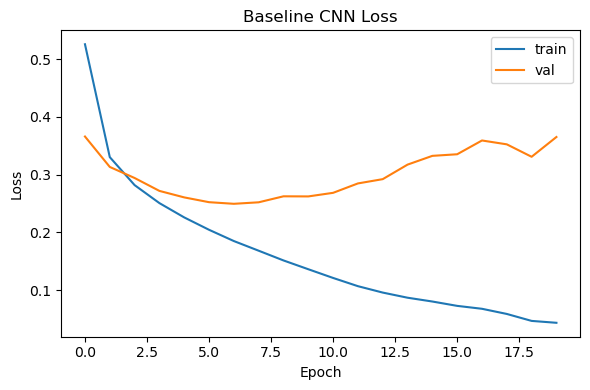

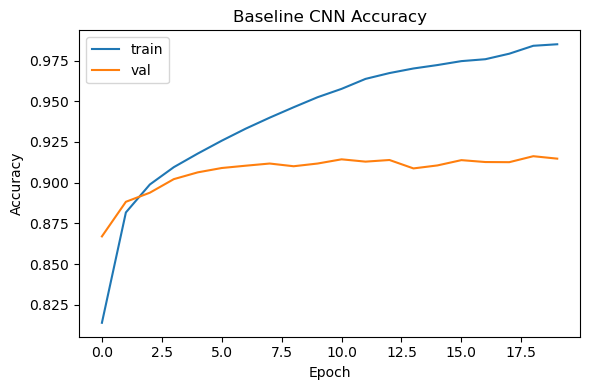

In [32]:
plot_history(history, title_prefix="Baseline CNN")

### Evaluate on the **test set**

In [33]:
test_loss, test_acc = model.evaluate(x_test_cnn, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

Test accuracy: 0.9138
Test loss: 0.4041


### Gathering model's summaries, metrics and artefacts

In [34]:
num_params = model.count_params()
print(f"Total parameters: {num_params}")

acc_per_10k_params = test_acc / (num_params / 10_000)
print(f"Accuracy per 10k params: {acc_per_10k_params:.4f}")

Total parameters: 421642
Accuracy per 10k params: 0.0217


In [36]:
def save_history_plots(history, out_prefix):
    hist = history.history
    
    # Loss
    plt.figure(figsize=(6, 4))
    plt.plot(hist["loss"], label="train")
    plt.plot(hist["val_loss"], label="val")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{out_prefix}_loss.png", dpi=150)
    plt.close()
    
    # Accuracy
    plt.figure(figsize=(6, 4))
    plt.plot(hist["accuracy"], label="train")
    plt.plot(hist["val_accuracy"], label="val")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{out_prefix}_accuracy.png", dpi=150)
    plt.close()

save_history_plots(history, "baseline_cnn")
print(f"Saved plots to: {FIG_DIR}")

# Save the model
model_path = MODEL_DIR / "baseline_cnn.keras"
model.save(model_path)
print(f"Saved model to: {model_path}",)

# Save metrics and settings
run_info = {
    "model_name": model.name,
    "seed": SEED,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "optimizer": "Adam",
    "learning_rate": 1e-3,
    "train_time_sec": train_time_sec,
    "num_params": int(num_params),
    "test_loss": float(test_loss),
    "test_accuracy": float(test_acc),
    "acc_per_10k_params": float(acc_per_10k_params),
    "final_train_accuracy": float(history.history["accuracy"][-1]),
    "final_val_accuracy": float(history.history["val_accuracy"][-1]),
}

log_path = LOG_DIR / "baseline_cnn_metrics.json"
with open(log_path, "w") as f:
    json.dump(run_info, f, indent=2)

print(f"Saved metrics to: {log_path}")

Saved plots to: outputs\figures
Saved model to: outputs\models\baseline_cnn.keras
Saved metrics to: outputs\logs\baseline_cnn_metrics.json
